In [56]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv


# Task 2: Data Preparation – Exploration Stage

In [57]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/mirichoi0218/insurance


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv("/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [61]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

The missing value check showed that all variables had zero missing values. This indicates that the dataset is complete and does not require any imputation before analysis.

In [62]:
df.duplicated().sum()

np.int64(1)

In [63]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

The duplicate check identified one duplicated row in the dataset. This duplicate record was removed to avoid giving repeated observations unnecessary influence in the analysis.

In [64]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


The summary statistics suggest that the numerical variables are within reasonable ranges. For example, age ranges from 18 to 64, children ranges from 0 to 5, and no negative values were found. Although bmi and charges show some large values, they may represent real observations rather than data entry errors, so they were retained for further analysis.

In [65]:
print(df['sex'].unique())
print(df['smoker'].unique())
print(df['region'].unique())

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


The categorical variables were also checked for consistency. The labels in sex, smoker, and region were all clearly defined and consistent, so no additional cleaning was needed for category names.

A quality check was performed before the exploratory analysis. The results showed that the dataset contains no missing values in any variable. One duplicated row was identified and removed. The summary statistics suggest that the numerical variables are within reasonable ranges, and the categorical variables have consistent labels, so only minimal cleaning was required before analysis.

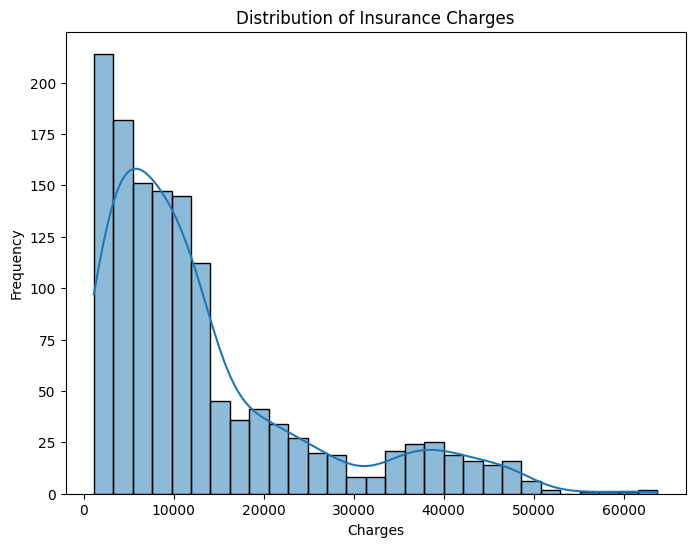

In [66]:
plt.figure(figsize=(8, 6))
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

A histogram was used to examine the distribution of the target variable, charges. The plot shows that most insurance charges are concentrated at lower values, while a smaller number of observations have very high charges, creating a right-skewed distribution. This means the response variable is not evenly distributed and may need special attention in later modelling.

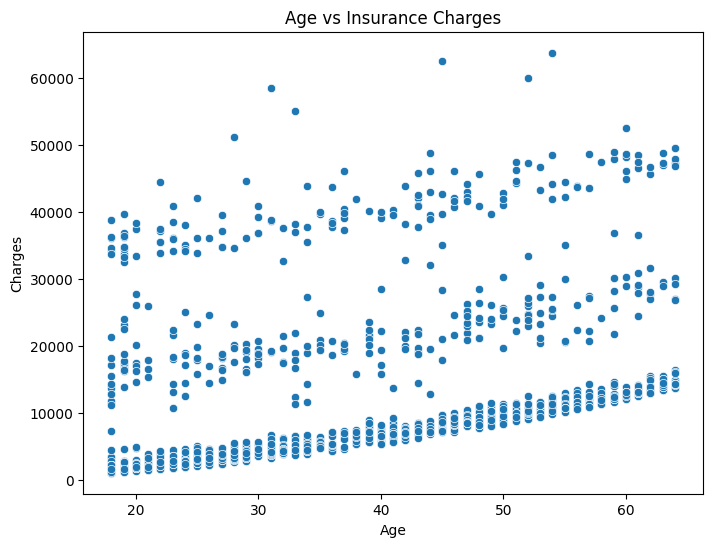

In [67]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='age', y='charges', data=df)
plt.title('Age vs Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

A scatterplot was used to explore the relationship between age and insurance charges. The plot suggests that older individuals tend to have higher charges overall, but the relationship is not perfectly linear and the points appear in several bands. This indicates that age is related to charges, while other factors may also play an important role in explaining the variation.

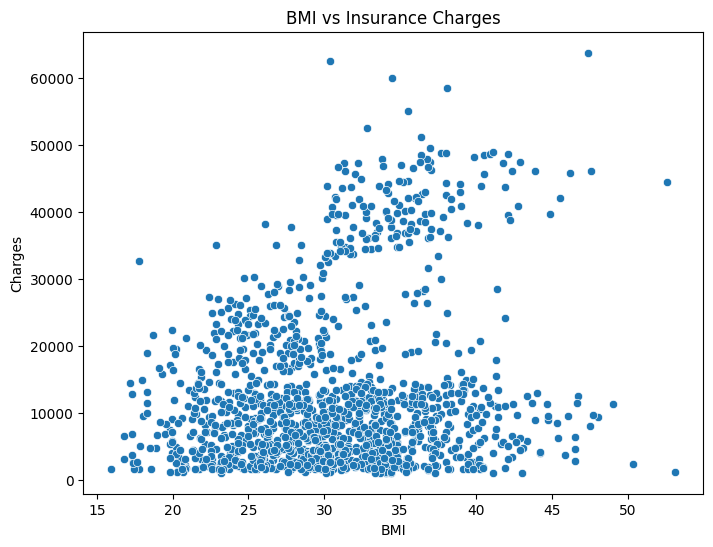

In [68]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

The plot does not show a strong linear relationship, although higher-charge observations appear more frequently at moderate to higher BMI levels. This suggests that BMI may contribute to insurance charges, but its effect is likely influenced by other factors as well.

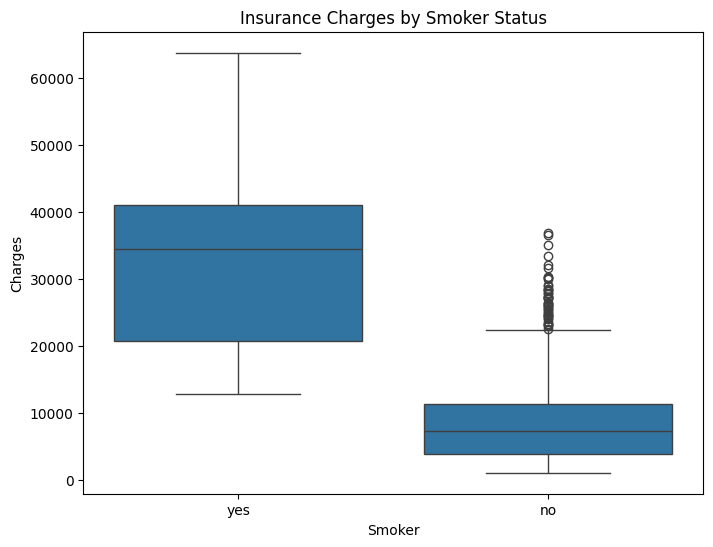

In [69]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Insurance Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

A boxplot was used to compare the distribution of insurance charges between smokers and non-smokers. The plot shows that smokers generally have much higher charges than non-smokers, and their charges are also more spread out. This means smoking status is likely to have a strong effect on the target variable and should be included in the regression model.

The exploratory plots suggest that insurance charges are right-skewed and are associated with several predictors, especially smoking status and age. Among the variables explored, smoker shows the clearest group difference, while age and BMI appear to have weaker or more variable relationships with charges. These findings support the use of a multiple regression model with both numerical and categorical predictors.

Part 3： Text cell: modelling choice

Based on the exploratory analysis, we selected a multiple linear regression model because the goal is to predict a continuous response variable, charges, using several numerical and categorical predictors at the same time. The plots suggested that variables such as age, BMI, and especially smoker status are related to insurance charges, so a regression model is appropriate for estimating these relationships together. We used one-hot encoding for the categorical variables and evaluated the model with R², RMSE, and MAE.

In [70]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R-squared:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

R-squared: 0.8069287081198011
RMSE: 5956.342894363588
MAE: 4177.045561036319


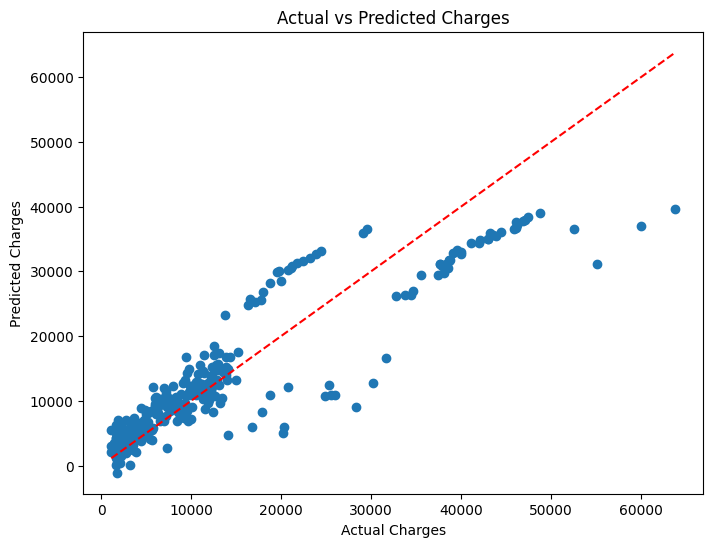

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

We used an actual-versus-predicted plot to evaluate how closely the regression model’s predictions matched the observed insurance charges. Most points lie reasonably close to the diagonal reference line, which suggests that the model captures the overall pattern in the data fairly well. However, the points are more spread out at higher charge levels, indicating that prediction errors are larger for some high-cost observations.

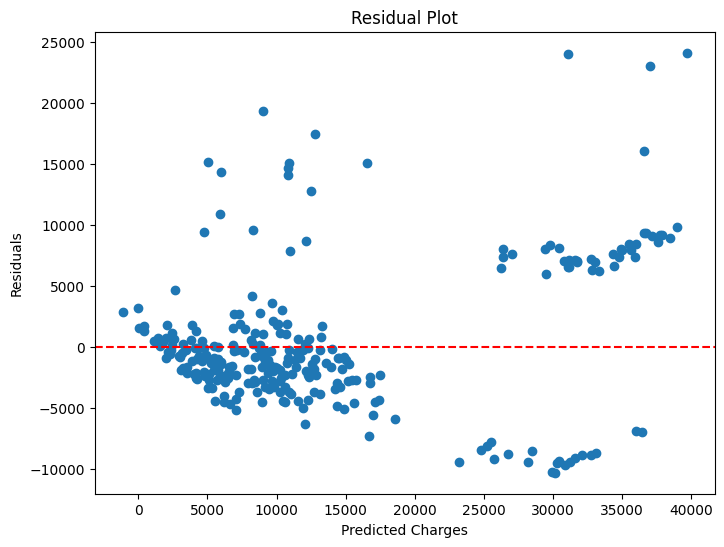

In [72]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

We used a residual plot to examine the pattern of prediction errors in the regression model. The residuals are not completely randomly scattered around zero, and the spread becomes larger for some higher predicted charge values. This suggests that the model performs reasonably well overall, but it does not fully capture all variation in insurance charges, especially for some higher-cost observations.